<a href="https://colab.research.google.com/github/tskir/london-housing/blob/main/planning_datahub_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Planning London Datahub — data pull and distribution exploration

This notebook queries the [Planning London Datahub](https://planningdata.london.gov.uk/api-guest/) (guest read-only Elasticsearch API), pulls a dataset of applications, and builds the initial distributions we discussed:

- Breakdown of `decision.raw` values
- Null rates for `intended_commencement_date` and `actual_commencement_date`
- Year-by-year population of those two date fields
- Lag distribution: `actual_commencement_date` − `intended_commencement_date` for the 2022 approved cohort
- Elapsed time for approved applications currently past their intended commencement date with no actual commencement recorded

**Note on data quality**: this is the same underlying source flagged in the GLA data register as *not quality-checked, self-reported by boroughs/applicants* — expect gaps, nulls, and some implausible dates. Sanity-check before trusting any distribution.

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import time

pd.set_option('display.max_columns', 100)

## Config

`FILTER_QUERY` is set to `match_all` by default so you pull everything. If the index turns out to be huge, uncomment the commented block to scope it down (e.g. to a valid_date range, or a single borough) before doing a full pull — cheaper to iterate on a subset first.

In [2]:
API_URL = "https://planningdata.london.gov.uk/api-guest"
INDEX = "applications"
HEADERS = {
    "X-API-AllowRequest": "be2rmRnt&",
    "Content-Type": "application/json",
}

PAGE_SIZE = 1000       # docs per scroll page
MAX_RECORDS = None     # set an int (e.g. 20000) to cap the pull while testing; None = pull everything

# Fields to bring back — extend this list as you need more later (e.g. parking, GIA, S106)
SOURCE_FIELDS = [
    "id",
    "lpa_name",
    "lpa_app_no",
    "borough",
    "ward",
    "application_type",
    "development_type",
    "status",
    "decision",
    "decision_date",
    "decision_target_date",
    "valid_date",
    "lapsed_date",
    "actual_commencement_date",
    "actual_completion_date",
    "application_details.intended_commencement_date",
    "application_details.intended_completion_date",
    "application_details.lead_developer_company_name",
    "application_details.building_age",
    "application_details.site_area",
]

# Default: pull everything. To scope down instead, comment the match_all line
# and uncomment/adjust the bool query below.
FILTER_QUERY = {"match_all": {}}

# FILTER_QUERY = {
#     "bool": {
#         "must": [
#             {"range": {"valid_date": {"gte": "01/01/2018"}}},
#             # {"term": {"decision.raw": "Approved"}},
#             # {"term": {"borough.raw": "Camden"}},
#         ]
#     }
# }

## Pull the data (scroll API)

The guest endpoint is a plain Elasticsearch 7.9 index, so we page through it with the scroll API rather than one giant request.

In [3]:
def fetch_all(index, query, source_fields, page_size=1000, max_records=None, scroll_ttl="2m", sleep_s=0.2):
    all_hits = []

    init_body = {
        "size": page_size,
        "query": query,
        "_source": source_fields,
    }
    resp = requests.post(
        f"{API_URL}/{index}/_search?scroll={scroll_ttl}",
        headers=HEADERS,
        json=init_body,
    )
    resp.raise_for_status()
    data = resp.json()

    total = data["hits"]["total"]["value"] if isinstance(data["hits"]["total"], dict) else data["hits"]["total"]
    print(f"Total matching documents: {total}")

    scroll_id = data.get("_scroll_id")
    hits = data["hits"]["hits"]

    while hits:
        all_hits.extend(hits)
        if max_records and len(all_hits) >= max_records:
            all_hits = all_hits[:max_records]
            break

        time.sleep(sleep_s)  # be polite to a small guest API
        scroll_resp = requests.post(
            f"{API_URL}/_search/scroll",
            headers=HEADERS,
            json={"scroll": scroll_ttl, "scroll_id": scroll_id},
        )
        scroll_resp.raise_for_status()
        data = scroll_resp.json()
        scroll_id = data.get("_scroll_id")
        hits = data["hits"]["hits"]

        if len(all_hits) % 5000 < page_size:
            print(f"  fetched {len(all_hits)} / {total}")

    # Clear the scroll context politely
    if scroll_id:
        requests.delete(f"{API_URL}/_search/scroll", headers=HEADERS, json={"scroll_id": scroll_id})

    print(f"Done — {len(all_hits)} records fetched.")
    return all_hits


raw_hits = fetch_all(INDEX, FILTER_QUERY, SOURCE_FIELDS, page_size=PAGE_SIZE, max_records=MAX_RECORDS)

Total matching documents: 1274018
  fetched 5000 / 1274018
  fetched 10000 / 1274018
  fetched 15000 / 1274018
  fetched 20000 / 1274018
  fetched 25000 / 1274018
  fetched 30000 / 1274018
  fetched 35000 / 1274018
  fetched 40000 / 1274018
  fetched 45000 / 1274018
  fetched 50000 / 1274018
  fetched 55000 / 1274018
  fetched 60000 / 1274018
  fetched 65000 / 1274018
  fetched 70000 / 1274018
  fetched 75000 / 1274018
  fetched 80000 / 1274018
  fetched 85000 / 1274018
  fetched 90000 / 1274018
  fetched 95000 / 1274018
  fetched 100000 / 1274018
  fetched 105000 / 1274018
  fetched 110000 / 1274018
  fetched 115000 / 1274018
  fetched 120000 / 1274018
  fetched 125000 / 1274018
  fetched 130000 / 1274018
  fetched 135000 / 1274018
  fetched 140000 / 1274018
  fetched 145000 / 1274018
  fetched 150000 / 1274018
  fetched 155000 / 1274018
  fetched 160000 / 1274018
  fetched 165000 / 1274018
  fetched 170000 / 1274018
  fetched 175000 / 1274018
  fetched 180000 / 1274018
  fetched 1850

## Flatten into a DataFrame

In [4]:
sources = [h["_source"] for h in raw_hits]
df = pd.json_normalize(sources, sep=".")

print(df.shape)
df.head()

(1274018, 20)


,lpa_name,development_type,actual_completion_date,decision,application_type,borough,ward,decision_date,decision_target_date,valid_date,lpa_app_no,actual_commencement_date,id,lapsed_date,status,application_details.intended_completion_date,application_details.intended_commencement_date,application_details.lead_developer_company_name,application_details.site_area,application_details.building_age
0,Islington,None,None,Approved,All Other,Islington,None,None,24/03/2025,28/01/2025,P2025/0271/FUL,None,Islington-P2025_0271_FUL,None,Withdrawn,08/2026,08/2025,Councillor Caroline Russell,NaN,NaN
1,Hackney,Other listed building consents (alter-extend),None,Refused,All Other,Hackney,De Beauvoir Ward,04/05/2022,04/05/2022,09/03/2022,2021/3412,None,Hackney-2021_3412,04/05/2022,Refused,NaN,NaN,NaN,NaN,NaN
2,Hackney,Certificates of Lawful Development,None,Approved,All Other,Hackney,Shacklewell Ward,19/04/2022,20/04/2022,23/02/2022,2021/3771,None,Hackney-2021_3771,19/04/2025,Approved,NaN,NaN,NaN,NaN,NaN
3,Lewisham,None,None,None,All Other,Lewisham,None,None,None,01/03/2022,DC/22/125077,None,Lewisham-DC_22_125077,None,Application Under Consideration,NaN,NaN,NaN,NaN,NaN
4,Barking & Dagenham,Certificates of Lawful Development,None,None,Householder,London Borough of Barking and Dagenham,Parsloes,None,None,None,23/01449/CLUP,None,Barking_&_Dagenham-23_01449_CLUP,None,Application Received,NaN,NaN,NaN,NaN,NaN


In [21]:
pd.set_option('display.max_rows', 1000)
pd.set_option('display.max_columns', None)
display(df)
pd.reset_option('display.max_rows')
pd.reset_option('display.max_columns')

,lpa_name,development_type,actual_completion_date,decision,application_type,borough,ward,decision_date,decision_target_date,valid_date,lpa_app_no,actual_commencement_date,id,lapsed_date,status,application_details.intended_completion_date,application_details.intended_commencement_date,application_details.lead_developer_company_name,application_details.site_area,application_details.building_age,commencement_lag_days,is_overdue_not_started,elapsed_since_intended_days,is_lapsed
0,Islington,None,NaT,Approved,All Other,Islington,None,NaT,2025-03-24,2025-01-28,P2025/0271/FUL,NaT,Islington-P2025_0271_FUL,NaT,Withdrawn,NaT,NaT,Councillor Caroline Russell,NaN,NaN,NaN,False,None,False
1,Hackney,Other listed building consents (alter-extend),NaT,Refused,All Other,Hackney,De Beauvoir Ward,2022-05-04,2022-05-04,2022-03-09,2021/3412,NaT,Hackney-2021_3412,2022-05-04,Refused,NaT,NaT,NaN,NaN,NaN,NaN,False,None,True
2,Hackney,Certificates of Lawful Development,NaT,Approved,All Other,Hackney,Shacklewell Ward,2022-04-19,2022-04-20,2022-02-23,2021/3771,NaT,Hackney-2021_3771,2025-04-19,Approved,NaT,NaT,NaN,NaN,NaN,NaN,False,None,True
3,Lewisham,None,NaT,None,All Other,Lewisham,None,NaT,NaT,2022-03-01,DC/22/125077,NaT,Lewisham-DC_22_125077,NaT,Application Under Consideration,NaT,NaT,NaN,NaN,NaN,NaN,False,None,False
4,Barking & Dagenham,Certificates of Lawful Development,NaT,None,Householder,London Borough of Barking and Dagenham,Parsloes,NaT,NaT,NaT,23/01449/CLUP,NaT,Barking_&_Dagenham-23_01449_CLUP,NaT,Application Received,NaT,NaT,NaN,NaN,NaN,NaN,False,None,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1274013,Lewisham,Other house holder developments,NaT,Approved,Householder,Lewisham,Ladywell,2022-01-18,2022-01-20,2021-11-11,DC/21/123769,NaT,Lewisham-DC_21_123769,2025-01-18,Approved,NaT,NaT,NaN,0.021,NaN,NaN,False,None,True
1274014,Ealing,None,NaT,Approved,All Other,London Borough of Ealing,SOUFLD,2023-12-12,2023-12-13,2023-10-19,233916ADV,NaT,Ealing-233916ADV,2028-12-12,Approved,NaT,NaT,NaN,NaN,NaN,NaN,False,None,True
1274015,Tower Hamlets,Other listed building consents (alter-extend),NaT,Refused,All Other,Tower Hamlets,Canary Wharf,2020-08-24,NaT,2020-06-29,PA/20/01358/NC,NaT,Tower_Hamlets-PA_20_01358_NC,2023-08-24,Refused,NaT,NaT,None,0.011,NaN,NaN,False,None,True
1274016,Tower Hamlets,None,NaT,Approved,All Other,Tower Hamlets,St Katharines and Wapping,2022-05-10,NaT,2022-04-07,PA/22/00666/S,NaT,Tower_Hamlets-PA_22_00666_S,2025-05-10,Approved,NaT,NaT,None,NaN,NaN,NaN,False,None,True


In [24]:
pd.set_option('display.max_rows', None)
counts = df['decision'].value_counts(dropna=False)
total_decisions = counts.sum()

# Calculate percentages and combine with counts
result = pd.DataFrame({
    'count': counts,
    'percentage': (counts / total_decisions * 100).round(2)
})

# Filter for counts > 100 and display
display(result[result['count'] > 100])
pd.reset_option('display.max_rows')

,count,percentage
decision,,
Approved,839626,65.90
Refused,153273,12.03
None,90115,7.07
Withdrawn,61607,4.84
No Objection to Proposal (OBS only),29602,2.32
Not Required,29018,2.28
Comment Issued,27415,2.15
Closed,13586,1.07
Unknown,5625,0.44


## Parse dates and build derived columns

In [ ]:
date_cols = [
    "decision_date",
    "decision_target_date",
    "valid_date",
    "lapsed_date",
    "actual_commencement_date",
    "actual_completion_date",
    "application_details.intended_commencement_date",
    "application_details.intended_completion_date",
]

for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], format="%d/%m/%Y", errors="coerce")

intended_col = "application_details.intended_commencement_date"
actual_col = "actual_commencement_date"

today = pd.Timestamp.today().normalize()

df["commencement_lag_days"] = (df[actual_col] - df[intended_col]).dt.days

df["is_overdue_not_started"] = (
    df[intended_col].notna()
    & (df[intended_col] < today)
    & df[actual_col].isna()
)
df["elapsed_since_intended_days"] = None
df.loc[df["is_overdue_not_started"], "elapsed_since_intended_days"] = (
    today - df.loc[df["is_overdue_not_started"], intended_col]
).dt.days

df["is_lapsed"] = df["lapsed_date"].notna()

## Distribution of `decision`

decision
Approved                               839626
Refused                                153273
None                                    90115
Withdrawn                               61607
No Objection to Proposal (OBS only)     29602
                                        ...  
NDACON                                      1
NOTPRO                                      1
NDAWDN                                      1
Decision Quashed                            1
Withdraw Notice                             1
Name: count, Length: 116, dtype: int64


/tmp/ipykernel_2597/2193327405.py:6: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


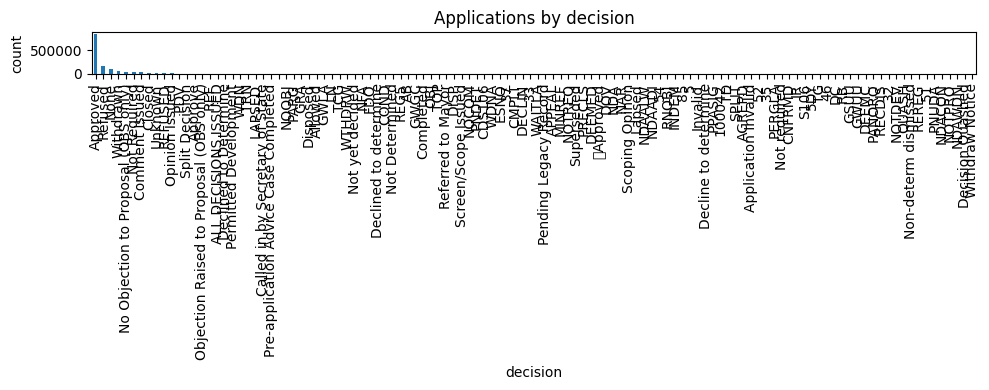

In [27]:
decision_counts = df["decision"].value_counts(dropna=False)
print(decision_counts)

decision_counts.plot(kind="bar", figsize=(10, 4), title="Applications by decision")
plt.ylabel("count")
plt.tight_layout()
plt.show()

## Null rates: intended vs actual commencement date

In [ ]:
null_summary = pd.DataFrame({
    "populated": [df[intended_col].notna().sum(), df[actual_col].notna().sum()],
    "null": [df[intended_col].isna().sum(), df[actual_col].isna().sum()],
}, index=["intended_commencement_date", "actual_commencement_date"])

null_summary["null_rate"] = null_summary["null"] / (null_summary["populated"] + null_summary["null"])
null_summary

## Population by year vs null

Counts of populated records per year for each date field. The null count from the table above tells you how many records don't show up in these histograms at all.

IndexError: index 0 is out of bounds for axis 0 with size 0

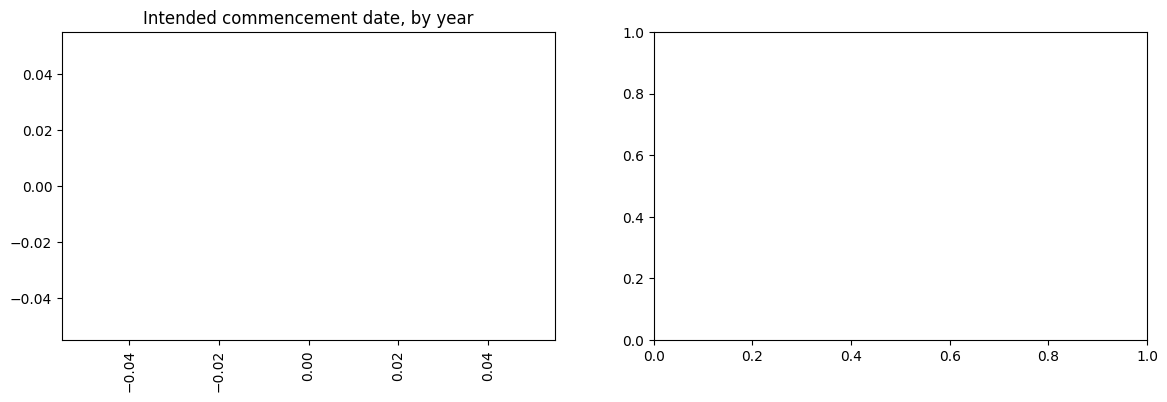

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df[intended_col].dt.year.value_counts().sort_index().plot(kind="bar", ax=axes[0], title="Intended commencement date, by year")
df[actual_col].dt.year.value_counts().sort_index().plot(kind="bar", ax=axes[1], title="Actual commencement date, by year")

for ax in axes:
    ax.set_ylabel("count")

plt.tight_layout()
plt.show()

## Lag distribution: 2022 intended-commencement, approved cohort

Adjust the `decision` filter value below once you've checked the exact label used in `decision_counts` above (e.g. it may be `"Approved"`, `"Granted"`, etc.).

In [ ]:
APPROVED_LABEL = "Approved"  # <-- confirm against decision_counts above

cohort_2022 = df[
    (df["decision"] == APPROVED_LABEL)
    & (df[intended_col].dt.year == 2022)
]

print(f"2022 intended-commencement approved cohort: {len(cohort_2022)}")
print(f"  of which actual_commencement_date populated: {cohort_2022[actual_col].notna().sum()}")

cohort_2022["commencement_lag_days"].dropna().plot(
    kind="hist", bins=40, figsize=(8, 4),
    title="Lag: actual vs intended commencement, 2022 cohort (days)"
)
plt.xlabel("days (actual - intended)")
plt.tight_layout()
plt.show()

cohort_2022["commencement_lag_days"].describe()

## Currently overdue, not yet started

Splits overdue-not-started applications from lapsed ones — a lapsed permission is dead, not "still waiting." Remember this is a censored sample (see earlier discussion): these elapsed times are a lower bound, not a like-for-like comparison against the completed 2022 lag distribution above.

In [ ]:
overdue = df[
    (df["decision"] == APPROVED_LABEL)
    & df["is_overdue_not_started"]
]

print(f"Overdue, not started: {len(overdue)}")
print(f"  of which lapsed: {overdue['is_lapsed'].sum()}")
print(f"  of which still live (not lapsed): {(~overdue['is_lapsed']).sum()}")

overdue.loc[~overdue["is_lapsed"], "elapsed_since_intended_days"].astype(float).plot(
    kind="hist", bins=40, figsize=(8, 4),
    title="Days overdue vs intended commencement (still live, not lapsed)"
)
plt.xlabel("days overdue")
plt.tight_layout()
plt.show()

## Save cleaned dataset for further work

In [ ]:
df.to_csv("planning_datahub_applications.csv", index=False)
print("Saved planning_datahub_applications.csv")